In [16]:
import numpy as np
from skimage import io
from skimage.measure import label, regionprops, regionprops_table
import pandas as pd
import matplotlib.pyplot as plt


In [17]:
file_path = r'C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\analysis\help aravind\pkc_test_image.npy'
npy_data = np.load(file_path, allow_pickle=True)


In [18]:
masks = npy_data[()]['masks'].astype('uint16')

In [7]:
type(masks)

numpy.ndarray

In [43]:

cell_1 = (masks[masks==1])
cell_1.shape

(1991,)

In [44]:
cell_1, cell_1.shape

(array([1, 1, 1, ..., 1, 1, 1], dtype=uint16), (1991,))

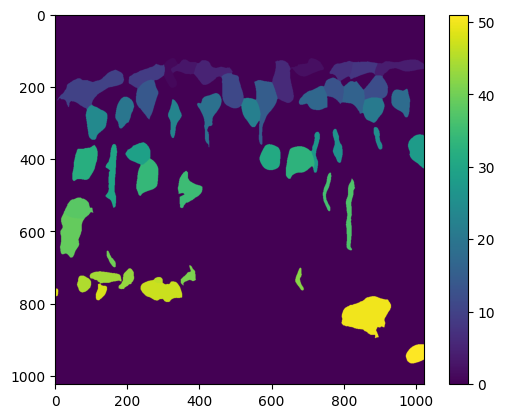

In [27]:
plt.imshow(masks)
plt.colorbar()

In [25]:
# --- 1. Save the segmentation as a binary (black and white) image ---
# The 'masks' array has 0 for background and a unique ID for each cell.
# We create a binary image where background is 0 (black) and all cells are 255 (white).

# Create a boolean array where pixels > 0 are True (cells) and others are False (background).
# Then, convert this boolean array to an 8-bit integer format (0 and 1) and multiply by 255.
binary_image = (masks > 0).astype(np.uint8) * 255

output_png_path = 'segmentation_output_binary.png'

# Save the resulting binary image.
io.imsave(output_png_path, binary_image)

print(f"Segmentation saved as a binary PNG at: {output_png_path}")

Segmentation saved as a binary PNG at: segmentation_output_binary.png


In [20]:
# --- 2. Calculate shape properties using regionprops ---
# The 'intensity_image' argument is used to calculate intensity-based properties,
# which we don't need here, so we can use the labeled_masks as the intensity image.
properties = [
    'label', 'area', 'perimeter', 'eccentricity',
    'major_axis_length', 'minor_axis_length',
    'solidity', 'orientation'
]
props = regionprops_table(labeled_masks, properties=properties)

# Create a pandas DataFrame from the properties dictionary
df = pd.DataFrame(props)

# Calculate circularity index (4 * pi * area / perimeter^2)
# Add it as a new column to the DataFrame
df['circularity'] = (4 * np.pi * df['area']) / (df['perimeter']**2)




In [21]:

# --- 3. Give the summary statistics of the calculated values ---
print("\nSummary statistics for each cell's shape properties:")
# Using .describe() to get summary statistics for all calculated properties
summary_stats = df.describe()
print(summary_stats)


Summary statistics for each cell's shape properties:
           label         area   perimeter  eccentricity  major_axis_length  \
count  51.000000    51.000000   51.000000     51.000000          51.000000   
mean   26.000000  3107.686275  252.514689      0.816026          94.365869   
std    14.866069  1880.947054   93.773529      0.136211          39.589822   
min     1.000000   164.000000   52.384776      0.524027          22.290605   
25%    13.500000  1938.500000  212.015765      0.714806          70.431717   
50%    26.000000  3106.000000  239.622366      0.839990          86.852264   
75%    38.500000  3940.500000  295.583784      0.934253         110.544866   
max    51.000000  9868.000000  525.363528      0.996654         219.616343   

       minor_axis_length   solidity  orientation  circularity  
count          51.000000  51.000000    51.000000    51.000000  
mean           44.813806   0.877421    -0.289627     0.605334  
std            18.311676   0.095980     0.765252   

In [22]:
df.head()

,label,area,perimeter,eccentricity,major_axis_length,minor_axis_length,solidity,orientation,circularity
0,1,1991.0,225.622366,0.923577,90.912234,34.856970,0.773504,0.040036,0.491492
1,2,2543.0,239.622366,0.883001,85.847734,40.294392,0.876292,-1.323852,0.556547
2,3,1886.0,199.509668,0.839990,69.562249,37.744611,0.865535,-1.475769,0.595420
3,4,3601.0,344.793939,0.975877,159.451214,34.811881,0.787104,-1.469621,0.380639
4,5,3875.0,298.149278,0.808266,99.950702,58.852675,0.836211,-1.553215,0.547790
